In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
FIGURE_DIR = OUTPUT_DIR / "figures"

EUROSAT_DIR = DATA_DIR / "eurosat" / "EuroSAT"

print(EUROSAT_DIR)

c:\Users\ASUS\dev\projects\satellite-project\data\eurosat\EuroSAT


In [2]:
print("Dataset Exists:", EUROSAT_DIR.exists())

classes = sorted(
    [
        folder.name
        for folder in EUROSAT_DIR.iterdir()
        if folder.is_dir()
    ]
)

print(f"\nNumber of Classes: {len(classes)}\n")

for cls in classes:
    print(cls)

Dataset Exists: True

Number of Classes: 10

AnnualCrop
Forest
HerbaceousVegetation
Highway
Industrial
Pasture
PermanentCrop
Residential
River
SeaLake


In [3]:
import pandas as pd

class_counts = []

for cls in classes:

    count = len(
        list((EUROSAT_DIR / cls).glob("*.jpg"))
    )

    class_counts.append(
        {
            "class": cls,
            "count": count
        }
    )

df_counts = pd.DataFrame(class_counts)

df_counts

,class,count
0,AnnualCrop,3000
1,Forest,3000
2,HerbaceousVegetation,3000
3,Highway,2500
4,Industrial,2500
5,Pasture,2000
6,PermanentCrop,2500
7,Residential,3000
8,River,2500
9,SeaLake,3000


In [4]:
total_images = df_counts["count"].sum()

print(f"Total Images: {total_images}")

Total Images: 27000


In [5]:
csv_path = FIGURE_DIR / "class_distribution.csv"

df_counts.to_csv(
    csv_path,
    index=False
)

print(csv_path)

c:\Users\ASUS\dev\projects\satellite-project\outputs\figures\class_distribution.csv


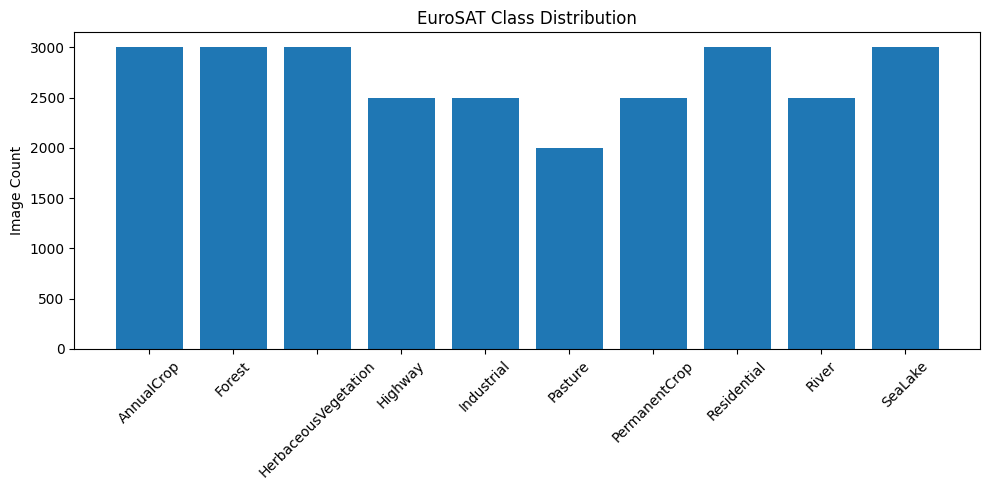

c:\Users\ASUS\dev\projects\satellite-project\outputs\figures\class_distribution.png


In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.bar(
    df_counts["class"],
    df_counts["count"]
)

plt.xticks(rotation=45)
plt.title("EuroSAT Class Distribution")
plt.ylabel("Image Count")

plt.tight_layout()

save_path = FIGURE_DIR / "class_distribution.png"

plt.savefig(save_path)

plt.show()

print(save_path)

In [7]:
print(df_counts)

print("\nMin Images:",
      df_counts["count"].min())

print("Max Images:",
      df_counts["count"].max())

                  class  count
0            AnnualCrop   3000
1                Forest   3000
2  HerbaceousVegetation   3000
3               Highway   2500
4            Industrial   2500
5               Pasture   2000
6         PermanentCrop   2500
7           Residential   3000
8                 River   2500
9               SeaLake   3000

Min Images: 2000
Max Images: 3000


In [8]:
from PIL import Image
import random
import matplotlib.pyplot as plt

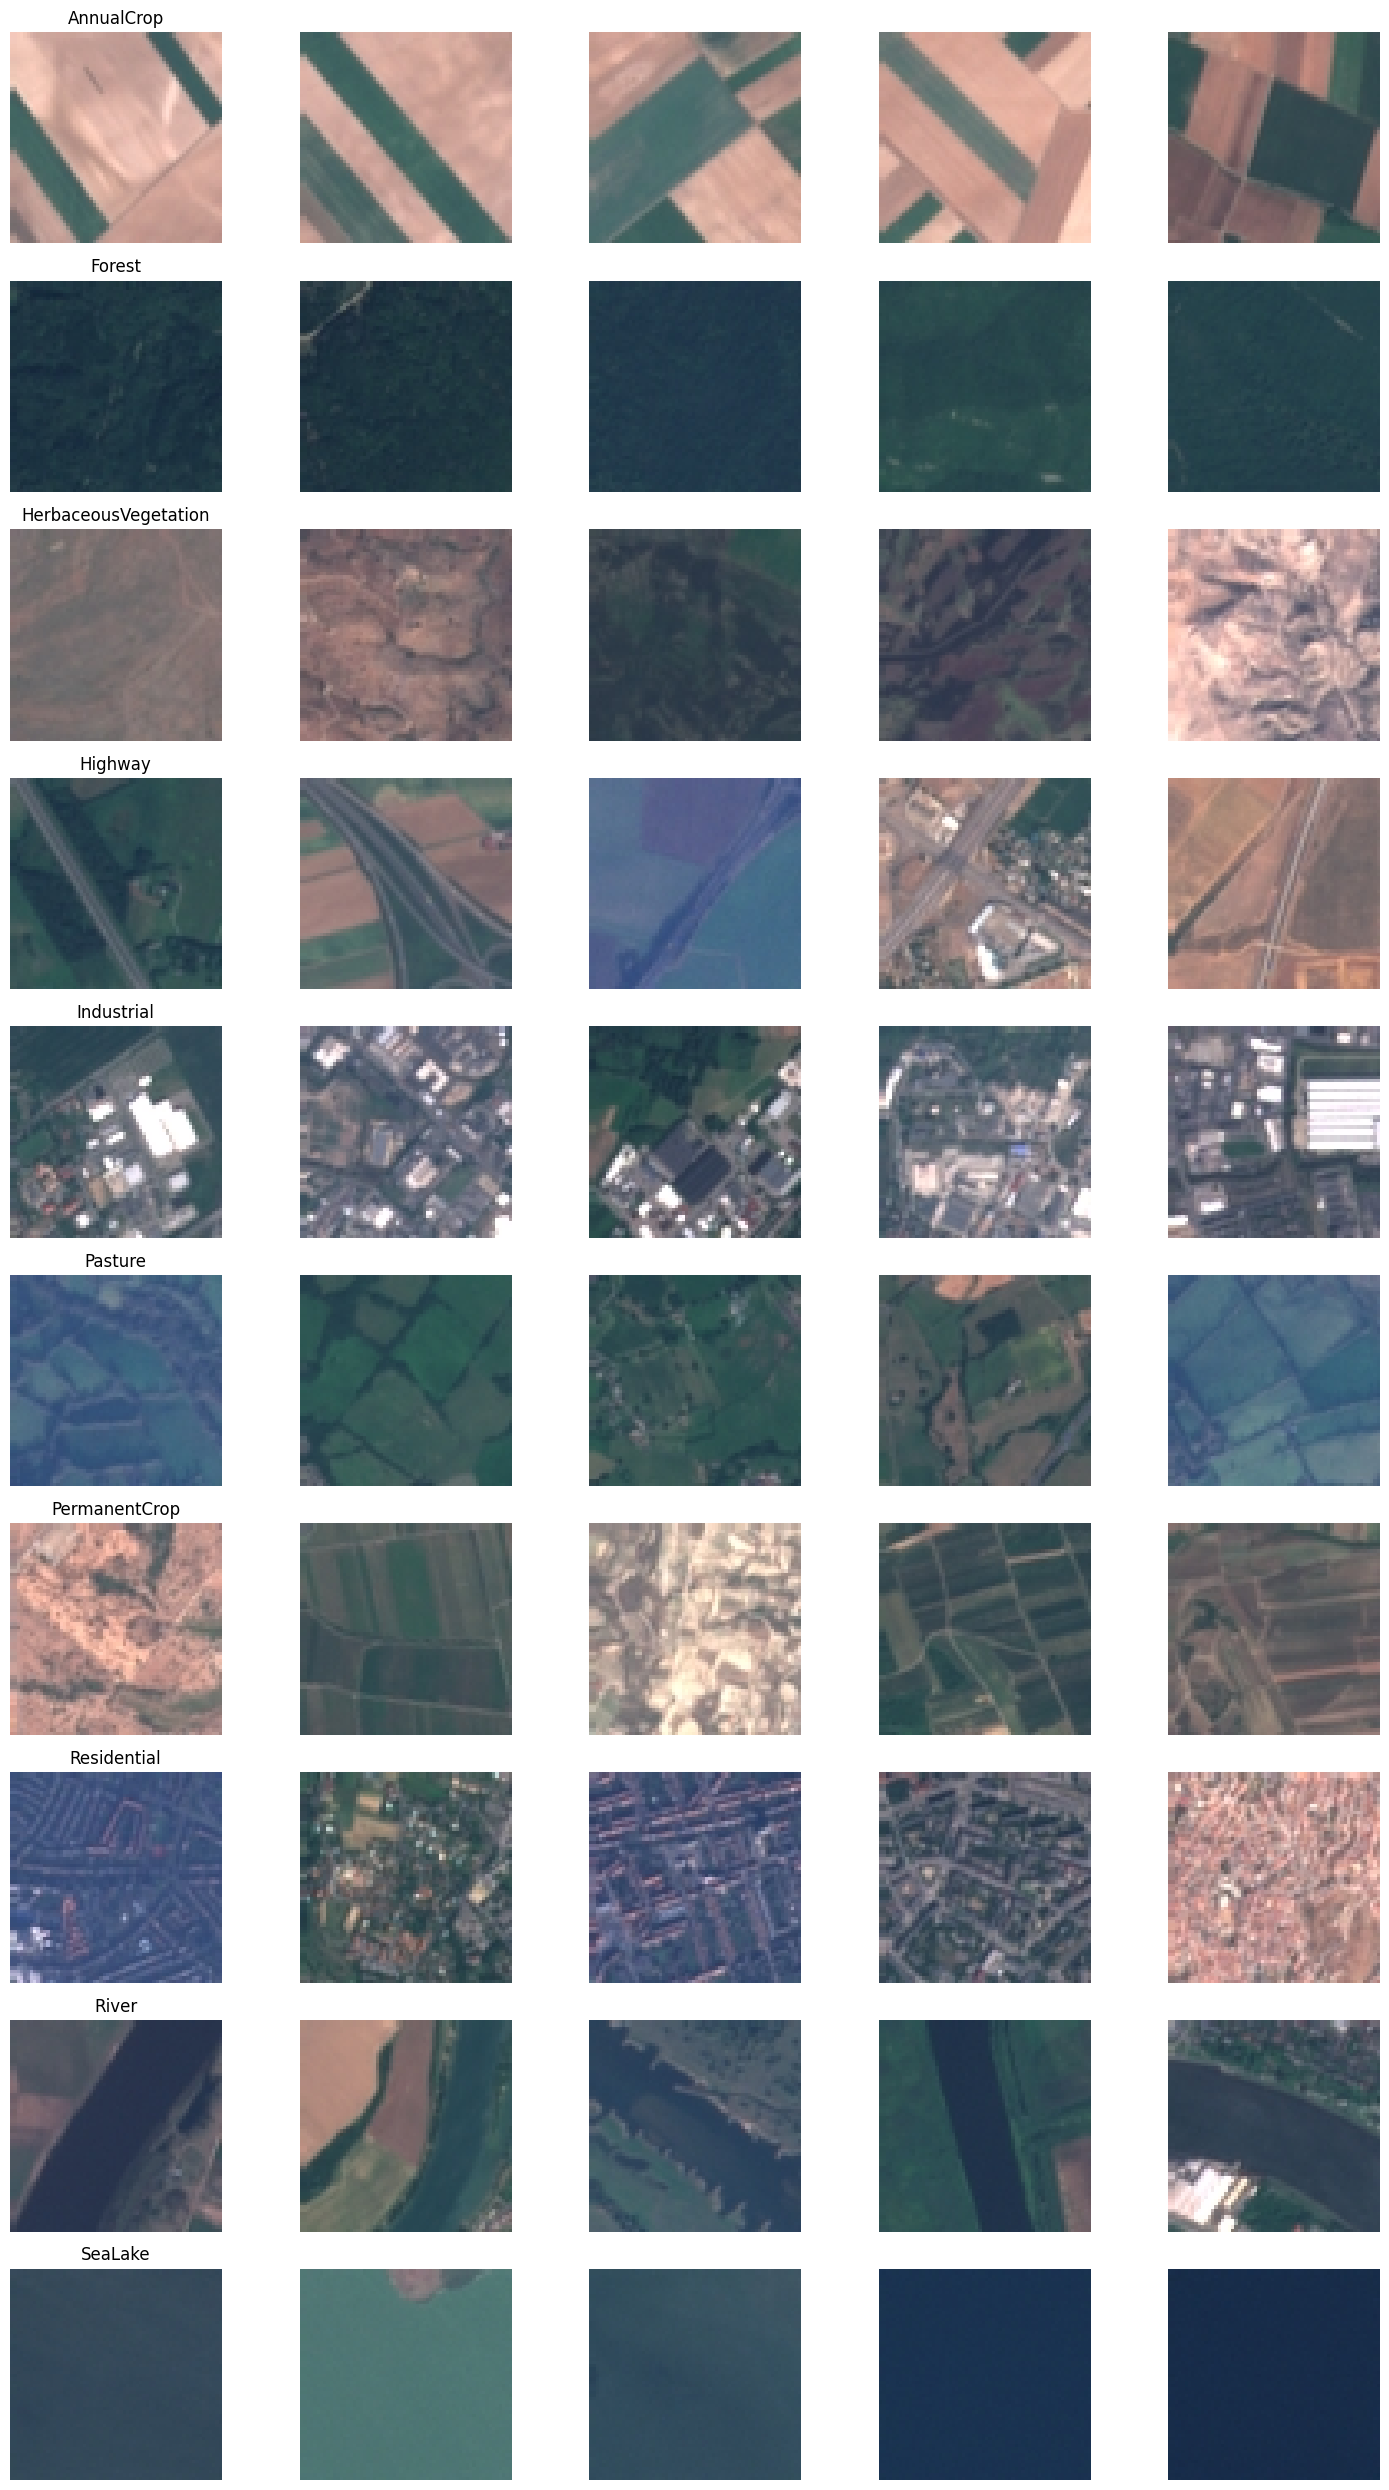

In [9]:
fig, axes = plt.subplots(
    len(classes),
    5,
    figsize=(15,25)
)

for row, cls in enumerate(classes):

    images = list(
        (EUROSAT_DIR / cls).glob("*.jpg")
    )

    selected = random.sample(images, 5)

    for col, img_path in enumerate(selected):

        img = Image.open(img_path)

        axes[row, col].imshow(img)
        axes[row, col].axis("off")

        if col == 0:
            axes[row, col].set_title(cls)

plt.tight_layout()

save_path = FIGURE_DIR / "sample_grid.png"

plt.savefig(save_path)

plt.show()

In [10]:
from PIL import Image

sample_image = next(
    (EUROSAT_DIR / classes[0]).glob("*.jpg")
)

img = Image.open(sample_image)

print("Image Size:", img.size)

Image Size: (64, 64)


In [11]:
records = []

for class_id, cls in enumerate(classes):

    image_paths = list(
        (EUROSAT_DIR / cls).glob("*.jpg")
    )

    for path in image_paths:

        records.append(
            {
                "filepath": str(path),
                "class_name": cls,
                "class_id": class_id
            }
        )

metadata_df = pd.DataFrame(records)

metadata_df.head()

,filepath,class_name,class_id
0,c:\Users\ASUS\dev\projects\satellite-project\d...,AnnualCrop,0
1,c:\Users\ASUS\dev\projects\satellite-project\d...,AnnualCrop,0
2,c:\Users\ASUS\dev\projects\satellite-project\d...,AnnualCrop,0
3,c:\Users\ASUS\dev\projects\satellite-project\d...,AnnualCrop,0
4,c:\Users\ASUS\dev\projects\satellite-project\d...,AnnualCrop,0


In [12]:
metadata_path = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "eurosat_metadata.csv"
)

metadata_df.to_csv(
    metadata_path,
    index=False
)

print(metadata_path)

c:\Users\ASUS\dev\projects\satellite-project\data\processed\eurosat_metadata.csv


In [13]:
from PIL import Image
import numpy as np
from tqdm import tqdm

In [14]:
image_paths = metadata_df["filepath"].tolist()

print("Images:", len(image_paths))

Images: 27000


In [15]:
channel_sum = np.zeros(3)
channel_sum_sq = np.zeros(3)

num_pixels = 0

for img_path in tqdm(image_paths):

    img = Image.open(img_path).convert("RGB")

    img = np.array(img, dtype=np.float32) / 255.0

    pixels = img.reshape(-1, 3)

    channel_sum += pixels.sum(axis=0)
    channel_sum_sq += (pixels ** 2).sum(axis=0)

    num_pixels += pixels.shape[0]

mean = channel_sum / num_pixels

std = np.sqrt(
    channel_sum_sq / num_pixels
    - mean ** 2
)

print("Mean:", mean)
print("Std:", std)

100%|██████████| 27000/27000 [00:12<00:00, 2187.66it/s]

Mean: [0.34437724 0.38029198 0.40777111]
Std: [0.20265734 0.13689059 0.11554374]


In [16]:
metadata_df["filepath"].sample(10).tolist()

['c:\\Users\\ASUS\\dev\\projects\\satellite-project\\data\\eurosat\\EuroSAT\\Residential\\Residential_1135.jpg',
 'c:\\Users\\ASUS\\dev\\projects\\satellite-project\\data\\eurosat\\EuroSAT\\Forest\\Forest_949.jpg',
 'c:\\Users\\ASUS\\dev\\projects\\satellite-project\\data\\eurosat\\EuroSAT\\Pasture\\Pasture_876.jpg',
 'c:\\Users\\ASUS\\dev\\projects\\satellite-project\\data\\eurosat\\EuroSAT\\AnnualCrop\\AnnualCrop_315.jpg',
 'c:\\Users\\ASUS\\dev\\projects\\satellite-project\\data\\eurosat\\EuroSAT\\PermanentCrop\\PermanentCrop_2353.jpg',
 'c:\\Users\\ASUS\\dev\\projects\\satellite-project\\data\\eurosat\\EuroSAT\\River\\River_2481.jpg',
 'c:\\Users\\ASUS\\dev\\projects\\satellite-project\\data\\eurosat\\EuroSAT\\Highway\\Highway_879.jpg',
 'c:\\Users\\ASUS\\dev\\projects\\satellite-project\\data\\eurosat\\EuroSAT\\Forest\\Forest_2042.jpg',
 'c:\\Users\\ASUS\\dev\\projects\\satellite-project\\data\\eurosat\\EuroSAT\\Forest\\Forest_2990.jpg',
 'c:\\Users\\ASUS\\dev\\projects\\satellite

In [17]:
from pathlib import Path

allbands_dir = PROJECT_ROOT / "data" / "eurosat" / "EuroSATallBands"

print("Exists:", allbands_dir.exists())

for item in sorted(allbands_dir.iterdir())[:20]:
    print(item.name)

Exists: True
AnnualCrop
Forest
HerbaceousVegetation
Highway
Industrial
label_map.json
Pasture
PermanentCrop
Residential
River
SeaLake
test.csv
train.csv
validation.csv


In [18]:
import pandas as pd

allbands_dir = PROJECT_ROOT / "data" / "eurosat" / "EuroSATallBands"

for file in ["train.csv", "validation.csv", "test.csv"]:

    df = pd.read_csv(allbands_dir / file)

    print("\n" + "="*50)
    print(file)
    print("="*50)

    print(df.shape)
    print(df.columns.tolist())

    display(df.head())


train.csv
(19317, 3)
['Filename', 'Label', 'ClassName']


,Filename,Label,ClassName
0,PermanentCrop/PermanentCrop_2401.tif,6,PermanentCrop
1,PermanentCrop/PermanentCrop_1006.tif,6,PermanentCrop
2,HerbaceousVegetation/HerbaceousVegetation_1025...,2,HerbaceousVegetation
3,SeaLake/SeaLake_1439.tif,9,SeaLake
4,River/River_1052.tif,8,River



validation.csv
(5519, 3)
['Filename', 'Label', 'ClassName']


,Filename,Label,ClassName
0,Residential/Residential_1716.tif,7,Residential
1,Residential/Residential_735.tif,7,Residential
2,SeaLake/SeaLake_2384.tif,9,SeaLake
3,AnnualCrop/AnnualCrop_2534.tif,0,AnnualCrop
4,PermanentCrop/PermanentCrop_1363.tif,6,PermanentCrop



test.csv
(2759, 3)
['Filename', 'Label', 'ClassName']


,Filename,Label,ClassName
0,HerbaceousVegetation/HerbaceousVegetation_2000...,2,HerbaceousVegetation
1,HerbaceousVegetation/HerbaceousVegetation_514.tif,2,HerbaceousVegetation
2,Residential/Residential_597.tif,7,Residential
3,River/River_2122.tif,8,River
4,SeaLake/SeaLake_2747.tif,9,SeaLake
